## Black-Scholes Real Data Calibration

In [1]:
# Magic commands for instant reloading of src code
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path
from dotenv import load_dotenv

# 1. Dynamically find the root folder ('options-projects-suite')
# Path.cwd() is the 'projects/subfolder', so we go up two levels.
root_dir = Path.cwd().parent.parent

# 2. Add root to system path so Python can find the 'src' package
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

# 3. Load the .env file explicitly from the root directory
load_dotenv(root_dir / ".env")

print(f"System path linked to: {root_dir}")

System path linked to: C:\Github Code\options-projects-suite


In [23]:
import pandas as pd
import numpy as np
import plotly.express as px  # Using Plotly for interactive charts
import plotly.graph_objects as go
import warnings
import matplotlib.pyplot as plt
import time
from scipy.optimize import differential_evolution, minimize


# Import your newly structured packages
from src.data.option_data_loader import MarketDataLoader
from src.models.option_pricing_math_engine import bs_call_price, implied_volatility

In [8]:
# Fetch the WRDS directory from your .env
env_path = os.environ.get("DATA_DIR")
if not env_path:
    raise ValueError("DATA_DIR not found. Check your .env file!")

# Build the exact path to the options data
options_dir = Path(env_path) / "WRDS Data" / "Options Data"

# Initialize the loader (this will trigger your print statements and load the df)
loader = MarketDataLoader(options_dir)

Loading Options, Spot, Yield, and Dividend Data into memory...
✅ Data Loaded Successfully.


In [11]:
# Define your target window
target_date = '2023-01-04'
target_exdate = '2023-02-17'

# Fetch S0, r, q, T, strikes, and prices
market_state = loader.get_market_state(target_date, target_exdate, strike_bound_pct=0.10)

S0 = market_state['S0']
T = market_state['T']
r = market_state['r']
q = market_state['q']
market_strikes = market_state['strikes']
market_prices = market_state['prices']

print(f"Market State Extracted:")
print(f"S0: {S0} | T: {T:.4f} | r: {r:.4f} | q: {q:.4f}")
print(f"Extracted {len(strikes)} valid call options.")

Market State Extracted:
S0: 3852.97 | T: 0.1205 | r: 0.0419 | q: 0.0157
Extracted 308 valid call options.


In [29]:
# 3. Calculate Market IVs
target_ivs, valid_strikes = [], []
for i, K in enumerate(market_strikes):
    iv = implied_volatility(market_prices[i], S0, K, T, r, q)
    if not np.isnan(iv):
        target_ivs.append(iv)
        valid_strikes.append(K)

valid_strikes = np.array(valid_strikes)
target_ivs = np.array(target_ivs)
print(f"✅ Ready! Targeting {len(valid_strikes)} liquid strikes.")

✅ Ready! Targeting 308 liquid strikes.


In [17]:
# --- BLACK-SCHOLES OBJECTIVE FUNCTION ---
def bs_objective(params):
    sigma = params[0]
    error = 0.0
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, K in enumerate(valid_strikes):
            # Price the option using a CONSTANT volatility
            m_price = bs_call_price(sigma, S0, K, T, r, q)
            m_iv = implied_volatility(m_price, S0, K, T, r, q)
            
            if np.isnan(m_iv): error += 5.0
            else: error += (m_iv - target_ivs[i])**2
                
    return error / len(valid_strikes)

# Guess 15% volatility
bs_guess = [0.15] 
bs_bounds = [(0.01, 1.0)]

print("Optimizing Constant Black-Scholes Volatility...")
res_bs = minimize(bs_objective, bs_guess, method='L-BFGS-B', bounds=bs_bounds)

best_sigma = res_bs.x[0]

print(f"✅ Finished!")
print(f"Optimal Constant Volatility: {best_sigma * 100:.2f}%")
print(f"Mean Squared Error: {res_bs.fun:.6f}")

Optimizing Constant Black-Scholes Volatility...
✅ Finished!
Optimal Constant Volatility: 20.89%
Mean Squared Error: 0.000412


Generating Black-Scholes Flat Line vs Market Smile...


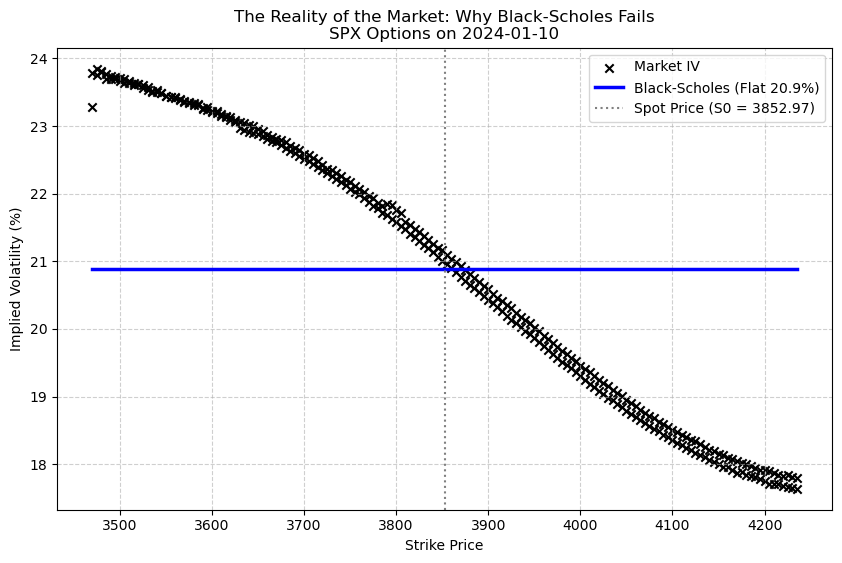

In [22]:
print("Generating Black-Scholes Flat Line vs Market Smile...")

# Black-Scholes assumes IV is exactly the same across every single strike
clean_strikes = np.linspace(min(valid_strikes), max(valid_strikes), 50)
bs_iv_line = np.full_like(clean_strikes, best_sigma) * 100

plt.figure(figsize=(10, 6))

# Plot Market Data
plt.scatter(valid_strikes, target_ivs * 100, color='black', label='Market IV', marker='x')

# Plot Black Scholes
plt.plot(clean_strikes, bs_iv_line, color='blue', label=f'Black-Scholes (Flat {best_sigma*100:.1f}%)', linewidth=2.5)

plt.axvline(S0, color='gray', linestyle=':', label=f'Spot Price (S0 = {S0})')
plt.title(f"The Reality of the Market: Why Black-Scholes Fails\nSPX Options on {TARGET_DATE}")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Heston Real Data Calibration
### Setup: Importing and Defining the State

In [26]:
from src.models.option_pricing_math_engine import heston_call_price, implied_volatility


### Calibration of the Heston Model

In [27]:
sample_step = max(1, len(valid_strikes) // 40) 

target_strikes_sampled = valid_strikes[::sample_step]
target_ivs_sampled = target_ivs[::sample_step]

print(f"Downsampled from {len(valid_strikes)} to {len(target_strikes_sampled)} strikes for 10x faster optimization.")

# --- UPDATE YOUR OBJECTIVE FUNCTION TO USE THE SAMPLED ARRAYS ---
def heston_objective(params):
    v0, kappa, theta, xi, rho = params
    error = 0.0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Loop through the SMALL array now
        for i, K in enumerate(target_strikes_sampled):
            m_price = heston_call_price(S0, K, T, r, q, v0, kappa, theta, xi, rho)
            m_iv = implied_volatility(m_price, S0, K, T, r, q)
            
            if np.isnan(m_iv): error += 5.0
            else: error += (m_iv - target_ivs_sampled[i])**2
                
    return error / len(target_strikes_sampled)

heston_bounds = [(0.01, 0.15), (0.5, 5.0), (0.01, 0.15), (0.05, 1.5), (-0.95, -0.4)]

print("Optimizing Heston Parameters (Hybrid Search)...")
start_time = time.time()

# Stage 1: Global Scout
res_global = differential_evolution(heston_objective, heston_bounds, popsize=8, maxiter=15, seed=42)

# Stage 2: Local Sniper
res_heston = minimize(heston_objective, res_global.x, method='L-BFGS-B', bounds=heston_bounds)

print(f"✅ Finished in {round(time.time() - start_time, 2)}s")
print(f"Optimal Parameters: {res_heston.x}")
print(f"Mean Squared Error: {res_heston.fun:.6f}")

Downsampled from 308 to 44 strikes for 10x faster optimization.
Optimizing Heston Parameters (Hybrid Search)...
✅ Finished in 146.99s
Optimal Parameters: [ 0.0454522   1.92358022  0.03994427  0.34491331 -0.91014774]
Mean Squared Error: 0.000005


### Visualising the Model against Live Data

Generating Heston Volatility Smile...


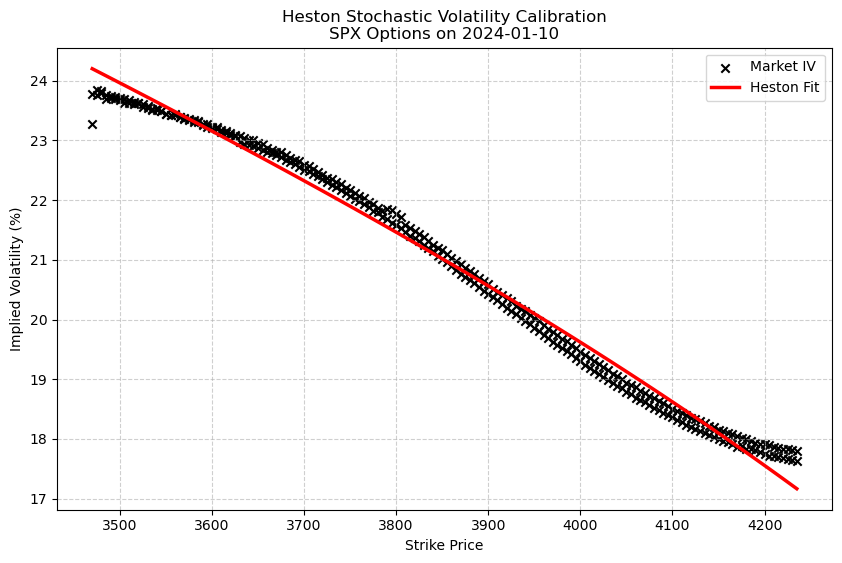

In [28]:
print("Generating Heston Volatility Smile...")

smooth_strikes = np.linspace(min(valid_strikes), max(valid_strikes), 50)
heston_prices = [heston_call_price(S0, k, T, r, q, *res_heston.x) for k in smooth_strikes]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    heston_iv = [implied_volatility(p, S0, k, T, r, q) for p, k in zip(heston_prices, smooth_strikes)]

valid_idx = ~np.isnan(heston_iv)
clean_strikes = np.array(smooth_strikes)[valid_idx]
clean_iv = np.array(heston_iv)[valid_idx] * 100

plt.figure(figsize=(10, 6))
plt.scatter(valid_strikes, target_ivs * 100, color='black', label='Market IV', marker='x')
plt.plot(clean_strikes, clean_iv, color='red', label='Heston Fit', linewidth=2.5)

plt.title(f"Heston Stochastic Volatility Calibration\nSPX Options on {TARGET_DATE}")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Merton Real Data Calibration

### Calibration of the Merton-Jump Model

In [8]:
# --- MERTON OBJECTIVE FUNCTION ---
def merton_objective(params):
    sigma, lam, mu_j, delta = params
    error = 0.0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, K in enumerate(valid_strikes):
            # Notice how clean this is because the math is hidden in your engine!
            m_price = merton_jump_call(S0, K, T, r, q, sigma, lam, mu_j, delta)
            m_iv = implied_volatility(m_price, S0, K, T, r, q)
            
            if np.isnan(m_iv): error += 5.0
            else: error += (m_iv - target_ivs[i])**2
                
    return error / len(valid_strikes)

# --- RUN OPTIMIZER ---
merton_guess = [0.15, 1.0, -0.15, 0.10] 
merton_bounds = [(0.05, 0.30), (0.1, 5.0), (-0.5, 0.0), (0.01, 0.30)]

print("Optimizing Merton Parameters...")
start_time = time.time()
res_merton = minimize(merton_objective, merton_guess, method='L-BFGS-B', bounds=merton_bounds)

print(f"✅ Finished in {round(time.time() - start_time, 2)}s")
print(f"Parameters: {res_merton.x}")

Optimizing Merton Parameters...
✅ Finished in 62.69s
Parameters: [ 0.08582077  0.99228655 -0.0824808   0.07785328]


In [ ]:
### Visualising the Model against Live Data

In [ ]:
print("Generating Volatility Smile...")

smooth_strikes = np.linspace(min(valid_strikes), max(valid_strikes), 50)
merton_prices = [merton_jump_call(S0, k, T, r, q, *res_merton.x) for k in smooth_strikes]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    merton_iv = [implied_volatility(p, S0, k, T, r, q) for p, k in zip(merton_prices, smooth_strikes)]

valid_idx = ~np.isnan(merton_iv)
clean_strikes = np.array(smooth_strikes)[valid_idx]
clean_iv = np.array(merton_iv)[valid_idx] * 100

plt.figure(figsize=(10, 6))
plt.scatter(valid_strikes, target_ivs * 100, color='black', label='Market IV', marker='x')
plt.plot(clean_strikes, clean_iv, color='blue', label='Merton Fit', linewidth=2.5)

plt.title(f"Merton Jump Diffusion Calibration\nSPX Options on {TARGET_DATE}")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Bates Real Data Calibration

In [33]:
from src.models.option_pricing_math_engine import bates_call_price, bates_objective


sample_step = max(1, len(valid_strikes) // 40) 
target_strikes_sampled = valid_strikes[::sample_step]
target_ivs_sampled = target_ivs[::sample_step]

print(f"Downsampled from {len(valid_strikes)} to {len(target_strikes_sampled)} strikes for 10x faster optimization.")

# Parameter Seeding: [v0, kappa, theta, xi, rho, lam, mu_j, delta]
bates_guess = [0.0115, 3.0293, 0.0684, 1.1963, -0.6572, 0.9923, -0.0825, 0.0779]

bates_bounds = [
    (0.005, 0.15), (0.5, 5.0), (0.005, 0.15), (0.05, 1.5), (-0.95, -0.2), # Heston components
    (0.0, 3.0), (-0.5, 0.0), (0.01, 0.3)                                  # Merton components
]

print("Optimizing Bates Parameters (Seeded Fast Search)...")
start_time = time.time()

# WRAPPER: Use lambda to inject the static variables into the objective function
res_bates = minimize(
    lambda params: bates_objective(params, S0, T, r, q, target_strikes_sampled, target_ivs_sampled), 
    bates_guess, 
    method='L-BFGS-B', 
    bounds=bates_bounds
)

print(f"✅ Finished in {round(time.time() - start_time, 2)}s")
print(f"Optimal Parameters: {res_bates.x}")
print(f"Mean Squared Error: {res_bates.fun:.6f}")

Downsampled from 308 to 44 strikes for 10x faster optimization.
Optimizing Bates Parameters (Seeded Fast Search)...
✅ Finished in 182.96s
Optimal Parameters: [ 0.01249019  3.11815513  0.14998015  0.37100849 -0.85313816  1.08489675
 -0.09471983  0.01      ]
Mean Squared Error: 0.000004


Generating Bates Volatility Smile...


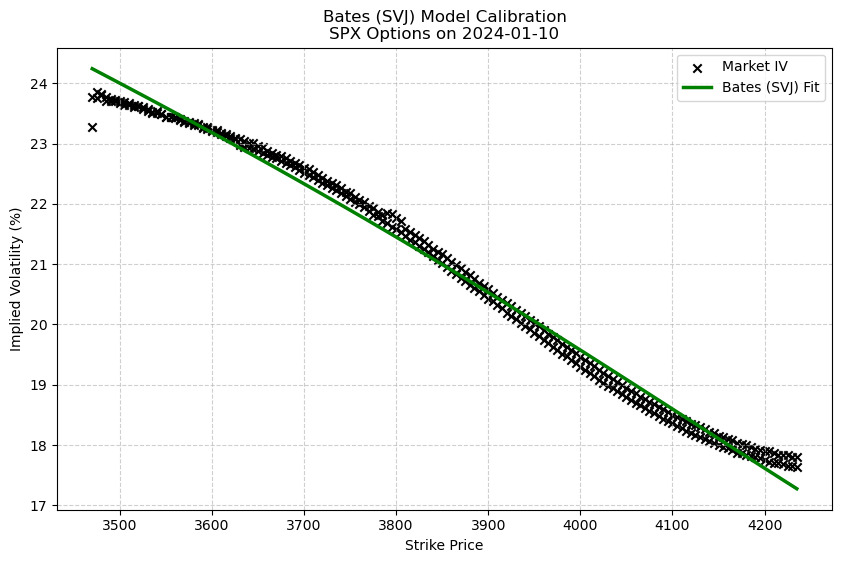


🏆 FINAL BATES PARAMETERS DICTIONARY (Copy this!)
bates_params = {
    'v0': 0.0125,
    'kappa': 3.1182,
    'theta': 0.1500,
    'xi': 0.3710,
    'rho': -0.8531,
    'lam': 1.0849,
    'mu_j': -0.0947,
    'delta': 0.0100
}


In [35]:
print("Generating Bates Volatility Smile...")

smooth_strikes = np.linspace(min(valid_strikes), max(valid_strikes), 50)
bates_prices = [bates_call_price(S0, k, T, r, q, *res_bates.x) for k in smooth_strikes]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bates_iv = [implied_volatility(p, S0, k, T, r, q) for p, k in zip(bates_prices, smooth_strikes)]

valid_idx = ~np.isnan(bates_iv)
clean_strikes = np.array(smooth_strikes)[valid_idx]
clean_iv = np.array(bates_iv)[valid_idx] * 100

plt.figure(figsize=(10, 6))
plt.scatter(valid_strikes, target_ivs * 100, color='black', label='Market IV', marker='x')
plt.plot(clean_strikes, clean_iv, color='green', label='Bates (SVJ) Fit', linewidth=2.5)

plt.title(f"Bates (SVJ) Model Calibration\nSPX Options on {TARGET_DATE}")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# SAVE THE FINAL PARAMETERS FOR NOTEBOOK 09
# ==========================================
print("\n" + "="*50)
print("🏆 FINAL BATES PARAMETERS DICTIONARY (Copy this!)")
print("="*50)
print("bates_params = {")
print(f"    'v0': {res_bates.x[0]:.4f},")
print(f"    'kappa': {res_bates.x[1]:.4f},")
print(f"    'theta': {res_bates.x[2]:.4f},")
print(f"    'xi': {res_bates.x[3]:.4f},")
print(f"    'rho': {res_bates.x[4]:.4f},")
print(f"    'lam': {res_bates.x[5]:.4f},")
print(f"    'mu_j': {res_bates.x[6]:.4f},")
print(f"    'delta': {res_bates.x[7]:.4f}")
print("}")

We need to calculate the Shadow Delta (or Skew-Adjusted Delta), which accounts for the fact that if the spot price drops, volatility will naturally spike, softening the blow for a long Call option.

Here is a block you can drop into your suite using Plotly  to visualize the difference between the naive BS Delta and the skew-aware Heston Delta.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from src.models.option_pricing_math_engine import bs_call_delta, heston_call_price

def calc_heston_shadow_delta(S, K, T, r, q, v0, kappa, theta, xi, rho, dS=0.1):
    """
    Calculates the Heston Delta using central finite difference.
    Because the Heston pricing function natively integrates the correlation (rho), 
    this numerical derivative inherently captures the skew-adjusted risk.
    """
    price_up = heston_call_price(S + dS, K, T, r, q, v0, kappa, theta, xi, rho)
    price_down = heston_call_price(S - dS, K, T, r, q, v0, kappa, theta, xi, rho)
    
    # Handle potential NaNs from the characteristic function integration
    if np.isnan(price_up) or np.isnan(price_down):
        return np.nan
        
    return (price_up - price_down) / (2 * dS)

print("Calculating Skew-Adjusted Greeks...")

# 1. Define range of spot prices around ATM
S_range = np.linspace(80, 120, 50)
K_fixed = 100.0
T_fixed = 0.5
r_fixed, q_fixed = 0.05, 0.0

# 2. Extract your optimized Heston parameters from Notebook 02
v0_opt, kappa_opt, theta_opt, xi_opt, rho_opt = res_heston.x

# 3. Calculate Deltas
bs_deltas = [bs_call_delta(S, K_fixed, T_fixed, r_fixed, q_fixed, np.sqrt(v0_opt)) for S in S_range]
heston_deltas = [calc_heston_shadow_delta(S, K_fixed, T_fixed, r_fixed, q_fixed, 
                                          v0_opt, kappa_opt, theta_opt, xi_opt, rho_opt) for S in S_range]

# 4. Plot using Plotly for interactivity
fig = go.Figure()

fig.add_trace(go.Scatter(x=S_range, y=bs_deltas, mode='lines', 
                         name='Black-Scholes Delta (Naive)', line=dict(color='blue', width=2, dash='dash')))
fig.add_trace(go.Scatter(x=S_range, y=heston_deltas, mode='lines', 
                         name=f'Heston Shadow Delta (\u03c1={rho_opt:.2f})', line=dict(color='red', width=3)))

fig.add_vline(x=K_fixed, line_width=1, line_dash="dot", line_color="black", annotation_text="Strike (ATM)")

fig.update_layout(
    title='Risk Management: Black-Scholes Naive Delta vs. Heston Shadow Delta',
    xaxis_title='Underlying Spot Price',
    yaxis_title='Option Delta (\u0394)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## 7. The Ultimate Fit: Local Volatility (Dupire)

While the Heston and Bates models attempt to capture the *dynamics* of the market by introducing new stochastic processes (variance and jumps), they are fundamentally **parametric** models. We try to find a few parameters ($\kappa, \theta, \rho, \lambda$) that best approximate the market. As seen in our calibrations, the fit is excellent, but rarely absolutely perfect.

In 1994, Bruno Dupire introduced a completely different paradigm: **Local Volatility**.

Instead of modeling volatility as a random variable, Dupire's equation treats volatility as a deterministic function of both the current asset price and time: $\sigma(S, t)$.

$$\sigma^2_{L}(K, T) = \frac{\frac{\partial C}{\partial T} + qC + K(r-q)\frac{\partial C}{\partial K}}{\frac{1}{2}K^2\frac{\partial^2 C}{\partial K^2}}$$

### Why does this matter?
1. **Perfect Calibration:** By definition, the Local Volatility model perfectly recovers all observed European option prices in the market. It is essentially an exact interpolation of the volatility surface.
2. **The Trade-off:** While Local Volatility gives a perfect fit *today*, its forward-looking dynamics are highly unrealistic. It predicts that the volatility smile will flatten over time, which empirically does not happen. 

**Conclusion for the Desk:** Stochastic models (like the Bates SVJ model calibrated above) are preferred for pricing exotic derivatives that depend heavily on forward volatility dynamics (like cliquets or forward-starting options). Local Volatility is preferred when pricing products that depend entirely on today's static vanilla surface.